# 4. Default Prediction: Tree-Based Models 

### Outline of this notebook:
* **Section 1:** Objective  
* **Section 2:** Load Cleaned Dataset  
* **Section 3:** Feature Preprocessing  
  * 3.1 Define feature types  
  * 3.2 Train-validation-test split (time-based)  
  * 3.3 Preprocessing for tree models  
* **Section 4:** Random Forest  
* **Section 5:** Gradient Boosting Model - XGBoost   
* **Section 6:** XGBoost Interpretation (SHAP Values)

---
## Section 1: Objective

In this notebook, we build and evaluate tree-based models for predicting loan default, including Random Forest and gradient boosting methods (XGBoost). 

Compared to logistic regression, these models can capture **nonlinear relationships and interactions** between variables without requiring manual feature engineering. As a result, they often achieve stronger predictive performance in credit risk settings.

The algorithm also provides measures of predictor importance, though these are **less immediately interpretable** than logistic regression coefficients, which have a clear relationship with changes in predicted risk.

---
## Section 2: Load Cleaned Dataset 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)

import time
from datetime import timedelta
import shap

In [5]:
df_cleaned = pd.read_parquet("../data/processed/LendingClub_cleaned.parquet")

In [6]:
df_cleaned.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,default,credit_age
0,5000.0,36.0,0.1065,162.87,B,B2,10.0,RENT,24000.0,Verified,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0,41.350685
1,2500.0,60.0,0.1527,59.83,C,C4,0.5,RENT,30000.0,Source Verified,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,1,27.095890
2,2400.0,36.0,0.1596,84.33,C,C5,10.0,RENT,12252.0,Not Verified,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0,24.506849
3,10000.0,36.0,0.1349,339.31,C,C1,10.0,RENT,49200.0,Source Verified,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0,30.260274
4,3000.0,60.0,0.1269,67.79,B,B5,1.0,RENT,80000.0,Source Verified,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0,30.345205


#### Limit to pre-COVID loans

To ensure a stable and consistent economic environment, I exclude observations from the COVID-19 period and restrict the analysis to loans issued up to 2019. This avoids potential distortions driven by the unprecedented shocks during the pandemic.

In [8]:
df_cleaned['issue_d'].agg(['min', 'max'])

min   2007-06-01
max   2020-09-01
Name: issue_d, dtype: datetime64[ns]

In [9]:
print(f"Number of observations before restricting to 2019-12-01: {df_cleaned.shape[0]:,}")

Number of observations before restricting to 2019-12-01: 1,860,765


In [10]:
df_cleaned = df_cleaned[df_cleaned['issue_d'] <= '2019-12-01']

In [11]:
print(f"Number of observations after restricting to 2019-12-01: {df_cleaned.shape[0]:,}")

Number of observations after restricting to 2019-12-01: 1,856,478


---
## Section 3: Feature Preprocessing

In this section, I prepare the features for tree-based models using a streamlined preprocessing pipeline.

The main steps are as follows:

- **3.1: Define feature types**: Separate variables into numerical and categorical features.

- **3.2: Train-validation-test split**

- **3.3: Build preprocessing pipeline**:
  - **Categorical variables**: Impute missing values using the most frequent value and apply one-hot encoding, converting each category into binary (0/1) indicator variables.
  - **Numerical variables**: Impute missing values using the median.
  - Unlike logistic regression, tree-based models do not require feature scaling, as they are not sensitive to the scale of input variables.
  - These steps are implemented using `ColumnTransformer` and `Pipeline` from `sklearn`, and are applied during model training rather than directly modifying `df_cleaned`. This ensures consistency, reproducibility, and prevents data leakage.

### 🔷 3.1: Define feature types

In [14]:
# 1. Target variable
target = 'default'

# 2. Variables to drop (before modeling)
drop_cols = ['zip_code', 'grade', 'addr_state']  
    # grade: 
    #  - redundant to 'sub_grade' (see 2_exploratory_data_analysis)
    # addr_state, zip_code:
    #  - will drop geographic variables 
    #    to avoid potential proxy effects for protected characteristics
    #    and mitigate fairness / regulatory concerns in credit risk modeling.

# 3. Time-related (handle separately)
date_cols = ['issue_d']

# 4. Categorical features
categorical_cols = [
    'sub_grade', 
    'home_ownership', 'verification_status',
    'purpose',
    'initial_list_status', 'application_type'
]

# 5. Numeric features (all the others)
numeric_cols = [
    col for col in df_cleaned.columns
    if col not in categorical_cols + date_cols + drop_cols + [target]
]

# 6. Final check
print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))
print("Date:", date_cols)

Numeric: 53
Categorical: 6
Date: ['issue_d']


In [15]:
# print(numeric_cols) ## Checking numeric features 

### 🔷 3.2: Train-validation-test split (time-based)

In [17]:
# Start from original data
X = df_cleaned.copy()

# Drop unnecessary columns
X = X.drop(columns=[col for col in drop_cols if col in X.columns])

# Target
y = df_cleaned[target]

# Combine
df_model = X.copy()
df_model[target] = y

# Sort by issue date
df_model = df_model.sort_values("issue_d")

# Split indices
n = len(df_model)
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

# Split data (time-based)
X_train = df_model.iloc[:train_end].drop(columns=[target])
y_train = df_model.iloc[:train_end][target]

X_val = df_model.iloc[train_end:val_end].drop(columns=[target])
y_val = df_model.iloc[train_end:val_end][target]

X_test = df_model.iloc[val_end:].drop(columns=[target])
y_test = df_model.iloc[val_end:][target]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (1113886, 60)
Validation size: (371296, 60)
Test size: (371296, 60)


In [18]:
# Check date ranges
print(f"Train date range: {X_train['issue_d'].min().date()} → {X_train['issue_d'].max().date()}")
print(f"Validation date range: {X_val['issue_d'].min().date()} → {X_val['issue_d'].max().date()}")
print(f"Test date range: {X_test['issue_d'].min().date()} → {X_test['issue_d'].max().date()}")

Train date range: 2007-06-01 → 2016-07-01
Validation date range: 2016-07-01 → 2017-08-01
Test date range: 2017-08-01 → 2019-12-01


In [19]:
# [Important] Drop time variable (not used for prediction)
X_train = X_train.drop(columns=["issue_d"])
X_val = X_val.drop(columns=["issue_d"]) 
X_test  = X_test.drop(columns=["issue_d"])

### 🔷 3.3: Build Preprocessing Pipeline

To ensure consistent and reproducible feature transformations, I construct a preprocessing pipeline using `ColumnTransformer` and `Pipeline` from `sklearn`.

- **Categorical variables**:
  - Missing values are imputed using the most frequent value.
  - Variables are then one-hot encoded, converting each category into a binary (0/1) indicator variable.

- **Numerical variables**:
  - Missing values are imputed using the median.
  - Unlike logistic regression, feature scaling is not applied, as tree-based models are not sensitive to the scale of input variables.

These transformations are applied within the modeling pipeline during training, rather than directly modifying the dataset. This ensures that the same preprocessing steps are consistently applied across training, validation, and test sets, and helps prevent data leakage.

In [21]:
# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Numerical pipeline (no scaling for tree models)
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Combined preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_cols),
    ("cat", cat_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready (tree-based).")

Preprocessing pipeline ready (tree-based).


---
## Section 4: Random Forest

In this section, we build a Random Forest model using the full feature set. 

We begin with Random Forest (rather than directly using boosting methods like XGBoost) because it provides a **strong, stable baseline** that is less sensitive to hyperparameters and easier to interpret. This helps establish a benchmark before moving to more complex models that may offer incremental gains at the cost of additional tuning. In addition, comparing Random Forest results with the logistic regression models from Notebook 3 allows us to assess **how much nonlinearities and interactions improve predictive performance**.

We perform **cross-validation** to tune key hyperparameters, particularly:
- `max_depth` (controls tree complexity)  
- `min_samples_leaf` (controls minimum observations per leaf)

Model performance is evaluated using standard metrics, including:
- **ROC-AUC** (discriminatory power)  
- **Precision and Recall** (classification performance at a chosen threshold)

Finally, we examine **feature importance** to understand which variables contribute most to predictions, noting that importance measures in tree-based models are less directly interpretable than coefficients in logistic regression.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 4.1 Baseline model
# -----------------------------
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [24]:
# Fit on training data
start = time.time()

# Fit model
rf_pipeline.fit(X_train, y_train)

end = time.time()

elapsed = timedelta(seconds=end - start)

print(f"Random Forest = Training time: {elapsed}")

Random Forest = Training time: 0:03:01.820129


In [25]:
# Try a few configurations
param_grid_rf = [
    {"max_depth": None, "min_samples_leaf": 5},
    {"max_depth": 10, "min_samples_leaf": 5},
    {"max_depth": 15, "min_samples_leaf": 10},
]

results_rf = []

for params in param_grid_rf:
    
    model_rf = Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    model_rf.fit(X_train, y_train)
    
    y_val_proba_rf = model_rf.predict_proba(X_val)[:, 1]
    auc_rf = roc_auc_score(y_val, y_val_proba_rf)
    
    results_rf.append({
        "params": params,
        "val_auc": auc_rf,
        "model": model_rf
    })

# Select best model
best_result_rf = max(results_rf, key=lambda x: x["val_auc"])
best_model_rf = best_result_rf["model"]

print("Best params:", best_result_rf["params"])
print("Best validation AUC:", best_result_rf["val_auc"])

Best params: {'max_depth': 15, 'min_samples_leaf': 10}
Best validation AUC: 0.7141110504701936


In [26]:
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_val, best_model_rf.predict_proba(X_val)[:, 1])

# Example: choose threshold manually
threshold_rf = 0.25

print(f"Chosen threshold: {threshold_rf}")

Chosen threshold: 0.25


In [27]:
y_test_proba_rf = best_model_rf.predict_proba(X_test)[:, 1]
y_test_pred_rf = (y_test_proba_rf >= threshold_rf).astype(int)

print("Test Performance:")
print("AUC:", roc_auc_score(y_test, y_test_proba_rf))
print("Precision:", precision_score(y_test, y_test_pred_rf))
print("Recall:", recall_score(y_test, y_test_pred_rf))
print("F1:", f1_score(y_test, y_test_pred_rf))

Test Performance:
AUC: 0.7062441733784104
Precision: 0.4176637488680954
Recall: 0.40959789712986644
F1: 0.413591501724643


#### Test Performance: Random Forest

The Random Forest model achieves **AUC ≈ 0.706**, indicating moderate discriminatory power. Precision (0.418) and recall (0.410) are both moderate, with an F1 score of 0.414, suggesting a balanced but imperfect ability to identify default cases.

Compared to the logistic regression model (full features), Random Forest shows a **small improvement in AUC** and slightly higher precision, but slightly lower recall. Overall, the differences are modest, suggesting that much of the predictive signal is already captured by the linear specification, and **nonlinearities play a relatively limited role** in this setting.

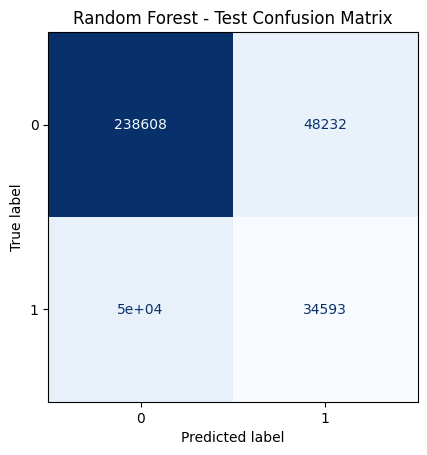

In [28]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues", colorbar=False)

plt.title("Random Forest - Test Confusion Matrix")
plt.show()

In [29]:
feature_names_rf = best_model_rf.named_steps["preprocess"].get_feature_names_out()
importances_rf = best_model_rf.named_steps["model"].feature_importances_

feat_imp_rf = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances_rf
}).sort_values("importance", ascending=False)

display(feat_imp_rf.head(20))

,feature,importance
2,num__int_rate,0.197975
1,num__term,0.109231
6,num__dti,0.038935
18,num__acc_open_past_24mths,0.036548
8,num__fico_range_low,0.035741
3,num__installment,0.024600
0,num__loan_amnt,0.024460
48,num__tot_hi_cred_lim,0.023348
19,num__avg_cur_bal,0.022471
5,num__annual_inc,0.021898


#### Feature Importance: Random Forest

The Random Forest model identifies **interest rate and loan term** as the most important predictors, followed by measures of **borrower financial condition and credit risk** such as DTI, FICO score, recent credit activity, and balances. This aligns with economic intuition: pricing variables and creditworthiness indicators are central to default risk.

Compared to logistic regression coefficients, these importance scores have a different interpretation.  
- In Random Forest, feature importance reflects **how much each variable contributes to improving prediction accuracy across the trees** (e.g., reducing impurity or improving splits).  
- In contrast, logistic regression coefficients measure the **direction and magnitude of effect on default probability (log-odds)**, holding other variables constant.

As a result, Random Forest importance:
- Does **not indicate direction** (positive vs. negative effect)  
- Can capture **nonlinear effects and interactions**  
- Is influenced by how often a feature is used in splits and how much it improves predictions  

Overall, the results suggest that while the key drivers are similar to the linear model, Random Forest captures their importance through **predictive contribution rather than interpretable marginal effects**.

---
## Section 5: Gradient Boosting Model - XGBoost   

In this section, we build a Gradient Boosting model using **XGBoost**, a widely used and high-performing tree-based method.

Unlike Random Forest, which builds many independent trees and averages their predictions, **XGBoost builds trees sequentially**, where each new tree focuses on correcting the errors of the previous ones. This often leads to **better predictive performance**, especially in complex datasets.

XGBoost is extremely popular in industry and data science competitions, and is increasingly used in credit risk modeling, particularly in fintech and advanced analytics teams. However, traditional banks may still rely more on logistic regression due to interpretability and regulatory requirements.

**Pros (vs. linear models)**
- Captures **nonlinear relationships and interactions automatically**
- Often achieves **higher predictive accuracy**
- Flexible and powerful with large datasets

**Cons (vs. linear models)**
- **Less interpretable** than logistic regression
- Requires more **hyperparameter tuning**
- Can be harder to justify in **regulated environments**

Overall, XGBoost provides a useful benchmark for understanding how much predictive performance can be gained from more flexible models.

In [32]:
## Build baseline pipeline
xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

In [33]:
## Fit on training data
start = time.time()

## Fit model
xgb_pipeline.fit(X_train, y_train)

end = time.time()

elapsed = timedelta(seconds=end - start)

print(f"XGBoost = Training time: {elapsed}")

XGBoost = Training time: 0:00:23.578384


In [34]:
param_grid_xgb = [
    {"max_depth": 4, "learning_rate": 0.1},
    {"max_depth": 6, "learning_rate": 0.05},
    {"max_depth": 8, "learning_rate": 0.03},
]

results_xgb = []

for params in param_grid_xgb:
    
    model_xgb = Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ))
    ])
    
    model_xgb.fit(X_train, y_train)
    
    y_val_proba_xgb = model_xgb.predict_proba(X_val)[:, 1]
    auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)
    
    results_xgb.append({
        "params": params,
        "val_auc": auc_xgb,
        "model": model_xgb
    })

best_result_xgb = max(results_xgb, key=lambda x: x["val_auc"])
best_model_xgb = best_result_xgb["model"]

print("Best params:", best_result_xgb["params"])
print("Best validation AUC:", best_result_xgb["val_auc"])

Best params: {'max_depth': 6, 'learning_rate': 0.05}
Best validation AUC: 0.7212509385206762


In [35]:
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_val, best_model_xgb.predict_proba(X_val)[:, 1]
)

threshold_xgb = 0.25

print(f"Chosen threshold (XGB): {threshold_xgb}")

Chosen threshold (XGB): 0.25


In [36]:
y_test_proba_xgb = best_model_xgb.predict_proba(X_test)[:, 1]
y_test_pred_xgb = (y_test_proba_xgb >= threshold_xgb).astype(int)

print("XGBoost Test Performance:")
print("AUC:", roc_auc_score(y_test, y_test_proba_xgb))
print("Precision:", precision_score(y_test, y_test_pred_xgb))
print("Recall:", recall_score(y_test, y_test_pred_xgb))
print("F1:", f1_score(y_test, y_test_pred_xgb))

XGBoost Test Performance:
AUC: 0.7154087848970019
Precision: 0.41675706165661475
Recall: 0.45491143317230276
F1: 0.4349992074454836


#### Test Performance: XGBoost (Comparison with RF and Logistic Regression)

The XGBoost model achieves **AUC ≈ 0.715**, which is noticably **higher** than both Random Forest (~0.706) and logistic regression (~0.702). This indicates a **meaningful improvement in discriminatory power**, suggesting that more flexible modeling of nonlinearities and interactions adds predictive value.

In terms of classification metrics, XGBoost shows **substantially higher recall (0.455 vs. 0.410–0.418)**, meaning it identifies more true defaulters. Precision (0.417) is similar to Random Forest and slightly higher than logistic regression, resulting in the **highest F1 score (0.435)** among all models.

Overall, these results suggest that XGBoost provides a **clear improvement over both linear and bagged tree models**, particularly in capturing default cases. This highlights the importance of nonlinear effects and interactions that simpler models are unable to fully exploit.

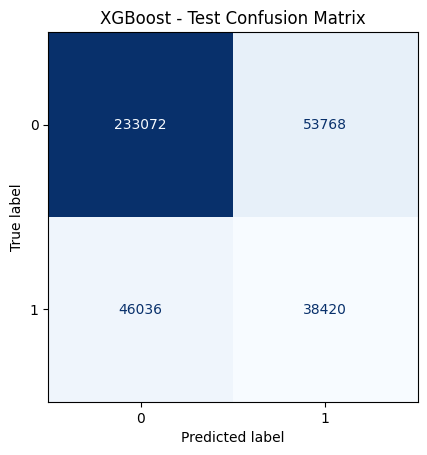

In [37]:
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap="Blues", colorbar=False)

plt.title("XGBoost - Test Confusion Matrix")
plt.show()

In [38]:
feature_names_xgb = best_model_xgb.named_steps["preprocess"].get_feature_names_out()
importances_xgb = best_model_xgb.named_steps["model"].feature_importances_

feat_imp_xgb = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb
}).sort_values("importance", ascending=False)

display(feat_imp_xgb.head(20))

,feature,importance
2,num__int_rate,0.109135
53,cat__sub_grade_A1,0.105235
1,num__term,0.087700
55,cat__sub_grade_A3,0.062733
54,cat__sub_grade_A2,0.053524
56,cat__sub_grade_A4,0.046814
57,cat__sub_grade_A5,0.042508
8,num__fico_range_low,0.030641
64,cat__sub_grade_C2,0.024969
18,num__acc_open_past_24mths,0.020966


#### Feature Importance: XGBoost

The XGBoost model identifies **interest rate, sub-grade categories, and loan term** as the most important features, followed by **credit quality (FICO score)** and measures of **recent credit activity and financial condition**. This is broadly consistent with the Random Forest results and reinforces that **pricing and creditworthiness signals are the primary drivers of default risk**.

Compared to Random Forest, the importance is more **concentrated among a smaller set of top features**, reflecting XGBoost’s sequential learning, where later trees focus on the most informative signals. Sub-grade categories appear prominently, indicating that the model leverages fine-grained credit risk segmentation.

Relative to logistic regression, these importance measures differ in interpretation:
- XGBoost importance reflects **how much each feature improves predictive performance across trees**  
- Logistic regression coefficients measure **direction and magnitude of effect on default probability (log-odds)**  

As a result, XGBoost:
- Does **not provide direction (positive vs. negative impact)**  
- Captures **nonlinearities and interactions**  
- May assign high importance to features that are useful in combination rather than individually  

Overall, while the key drivers are similar across models, XGBoost highlights their importance through **predictive contribution**, offering a different perspective from the more interpretable but restrictive linear model.